In [1]:
import pandas as pd

print(pd.__version__)

3.0.3


# Data Loading

This section loads the cleaned sales, calendar, and price datasets that will be used to build the data marts. These datasets were prepared during the data cleaning and preprocessing phase.

In [2]:
import pandas as pd

sales = pd.read_csv("../data/processed/sales_train_validation_cleaned.csv.gz")
calendar = pd.read_csv("../data/processed/calendar_cleaned.csv.gz")
prices = pd.read_csv("../data/processed/sell_prices_cleaned.csv.gz")

print("Sales Shape:", sales.shape)
print("Calendar Shape:", calendar.shape)
print("Prices Shape:", prices.shape)

Sales Shape: (30490, 1919)
Calendar Shape: (1969, 20)
Prices Shape: (6841121, 4)


The datasets were successfully loaded and verified before proceeding with the mart creation process.

## Data Validation

The column names of the sales, calendar, and price datasets were reviewed to verify the available fields and ensure consistency before creating the marts.

In [3]:
print("SALES")
print(sales.columns.tolist())

print("\nCALENDAR")
print(calendar.columns.tolist())

print("\nPRICES")
print(prices.columns.tolist())

SALES
['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4', 'd_5', 'd_6', 'd_7', 'd_8', 'd_9', 'd_10', 'd_11', 'd_12', 'd_13', 'd_14', 'd_15', 'd_16', 'd_17', 'd_18', 'd_19', 'd_20', 'd_21', 'd_22', 'd_23', 'd_24', 'd_25', 'd_26', 'd_27', 'd_28', 'd_29', 'd_30', 'd_31', 'd_32', 'd_33', 'd_34', 'd_35', 'd_36', 'd_37', 'd_38', 'd_39', 'd_40', 'd_41', 'd_42', 'd_43', 'd_44', 'd_45', 'd_46', 'd_47', 'd_48', 'd_49', 'd_50', 'd_51', 'd_52', 'd_53', 'd_54', 'd_55', 'd_56', 'd_57', 'd_58', 'd_59', 'd_60', 'd_61', 'd_62', 'd_63', 'd_64', 'd_65', 'd_66', 'd_67', 'd_68', 'd_69', 'd_70', 'd_71', 'd_72', 'd_73', 'd_74', 'd_75', 'd_76', 'd_77', 'd_78', 'd_79', 'd_80', 'd_81', 'd_82', 'd_83', 'd_84', 'd_85', 'd_86', 'd_87', 'd_88', 'd_89', 'd_90', 'd_91', 'd_92', 'd_93', 'd_94', 'd_95', 'd_96', 'd_97', 'd_98', 'd_99', 'd_100', 'd_101', 'd_102', 'd_103', 'd_104', 'd_105', 'd_106', 'd_107', 'd_108', 'd_109', 'd_110', 'd_111', 'd_112', 'd_113', 'd_114', 'd_115', 'd_1

## Feature Dataset Loading

The feature-engineered dataset was loaded and reviewed before creating the marts. This dataset contains the derived time-series features used during the transformation phase.

In [4]:
features = pd.read_csv("../data/processed/features_engineered_complete.csv")

print(features.shape)
print(features.columns.tolist())

(1913, 31)
['d', 'total_sales', 'date', 'month', 'year', 'event_name_1', 'event_type_1', 'snap_CA', 'snap_TX', 'snap_WI', 'wm_yr_wk', 'snap_active', 'day_of_week', 'is_weekend', 'day_of_year', 'week_of_year', 'is_holiday', 'is_snap_day', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_30', 'month_sin', 'month_cos', 'day_sin', 'day_cos', 'avg_price', 'price_lag_7', 'price_change']


# Store, State and Product Mart Creation

This section creates summary-level marts by aggregating total sales across stores, states, and products. These marts provide a simplified view of sales performance for downstream analysis and reporting.

In [5]:
import pandas as pd

sales = pd.read_csv("../data/processed/sales_train_validation_cleaned.csv.gz")

print(sales.shape)

(30490, 1919)


In [6]:
sales_cols = [col for col in sales.columns if col.startswith("d_")]

print("Number of sales columns:", len(sales_cols))

Number of sales columns: 1913


The daily sales columns were aggregated to calculate total sales for each product across the available time period.

In [7]:
sales["total_sales"] = sales[sales_cols].sum(axis=1)


C:\Users\Admin\AppData\Local\Temp\ipykernel_16080\3422520671.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales["total_sales"] = sales[sales_cols].sum(axis=1)


## State Mart

State-level sales were aggregated to compare sales performance across different regions.

In [8]:
state_mart = sales.groupby("state_id", as_index=False)["total_sales"].sum()

state_mart.head()

,state_id,total_sales
0,CA,28675547
1,TX,18899006
2,WI,18120856


## Product Mart

Product-level sales were aggregated to identify the highest and lowest selling items.

In [9]:
product_mart = sales.groupby("item_id", as_index=False)["total_sales"].sum()

product_mart.head()

,item_id,total_sales
0,FOODS_1_001,12247
1,FOODS_1_002,7334
2,FOODS_1_003,13394
3,FOODS_1_004,129481
4,FOODS_1_005,22914


In [10]:
import pandas as pd

sales = pd.read_csv("../data/processed/sales_train_validation_cleaned.csv.gz")

print(sales.shape)

(30490, 1919)


In [11]:
sales_cols = [col for col in sales.columns if col.startswith("d_")]

print("Number of sales columns:", len(sales_cols))

Number of sales columns: 1913


In [12]:
sales["total_sales"] = sales[sales_cols].sum(axis=1)

C:\Users\Admin\AppData\Local\Temp\ipykernel_16080\591823127.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales["total_sales"] = sales[sales_cols].sum(axis=1)


In [13]:
store_mart = sales.groupby("store_id", as_index=False)["total_sales"].sum()

store_mart.head()

,store_id,total_sales
0,CA_1,7698216
1,CA_2,5685475
2,CA_3,11188180
3,CA_4,4103676
4,TX_1,5595292


In [14]:
state_mart = sales.groupby("state_id", as_index=False)["total_sales"].sum()

state_mart.head()

,state_id,total_sales
0,CA,28675547
1,TX,18899006
2,WI,18120856


In [15]:
product_mart = sales.groupby("item_id", as_index=False)["total_sales"].sum()

product_mart.head()

,item_id,total_sales
0,FOODS_1_001,12247
1,FOODS_1_002,7334
2,FOODS_1_003,13394
3,FOODS_1_004,129481
4,FOODS_1_005,22914


# Exporting Data Marts

The generated marts were exported as CSV files for downstream analysis, reporting, and forecasting activities.

In [16]:
store_mart.to_csv("store_mart.csv", index=False)
state_mart.to_csv("state_mart.csv", index=False)
product_mart.to_csv("product_mart.csv", index=False)

# Mart Validation and Analysis

To validate the generated marts and understand the overall sales pattern in the dataset, a time-series view of total sales was created. This helps identify general trends and seasonality across the available sales history.

In [19]:
sales_cols = [col for col in sales.columns if col.startswith("d_")]

store_time = sales.groupby("store_id")[sales_cols].sum().T
store_time.index.name = "day"
store_time = store_time.reset_index()

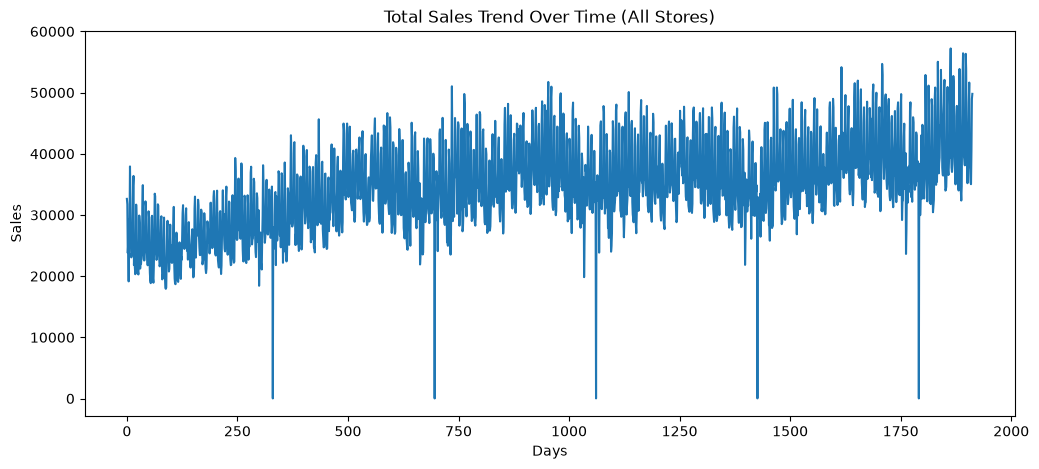

In [20]:
import matplotlib.pyplot as plt

store_time["total_sales"] = store_time.drop("day", axis=1).sum(axis=1)

plt.figure(figsize=(12,5))
plt.plot(store_time["total_sales"])
plt.title("Total Sales Trend Over Time (All Stores)")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()